# Stage 1 — Business Understanding, Data Preparation, EDA & Feature Engineering
### Capstone Project: Analysing Insurance Claims for SafeDrive Insurance Ltd.

**Notebook:** `data_preprocessing_eda_feature_engineering.ipynb`

This notebook covers Tasks 1.1–1.4 of the capstone:
1. Business understanding & success metrics
2. Loading, inspecting and cleaning the dataset
3. Exploratory Data Analysis (univariate & bivariate)
4. Feature engineering & multicollinearity check (VIF)

**Output:** `cleaned_dataset.csv` — the analysis-ready dataset used as input to Stage 2 (model building).

## Task 1.1 — Business Understanding & Success Metrics

**Analytical objective:** Build a predictive model that estimates the probability that a policyholder
will file a motor insurance claim during the policy period, using policy, policyholder, and vehicle
attributes available at underwriting time.

**Expected business outcome:** Underwriting and risk teams get an early, data-driven risk flag for
each policyholder, in addition to manual assessment, so pricing and risk-mitigation actions can be
taken *before* a claim is filed rather than after.

**Target audience:** Underwriting managers, risk/actuarial analysts, and pricing teams at SafeDrive
Insurance Ltd.

**Business questions this analysis should answer:**
1. Which vehicle and policyholder characteristics (e.g. vehicle age, safety equipment, population
   density of the policyholder's area) are most associated with a higher claim rate?
2. Do older / less-safety-equipped vehicles show a materially different claim rate than newer,
   well-equipped ones — and can we quantify that gap?
3. Can policyholders be segmented into risk bands (e.g. by vehicle age, safety score, area density)
   that show a clearly different claim incidence, so underwriting can apply differentiated scrutiny?

**Business success metrics** (what "success" looks like for SafeDrive):
1. **Reduction in claim-related loss ratio** — fewer high-risk policies written without a premium
   adjustment or risk mitigation step.
2. **Underwriting efficiency** — a measurable share of policies auto-flagged as low-risk / high-risk,
   reducing manual review time per policy.
3. **Earlier intervention rate** — proportion of eventual claimants who were flagged high-risk at
   underwriting time, enabling proactive risk management (e.g. inspection requirements, premium
   loading).

**Model evaluation metrics** (why each matters here, given claims are a small ~6% minority class):
1. **Recall (of the claim class)** — missing an actual claimant (false negative) is the costliest
   error for an insurer, since that risk goes completely unpriced; recall tells us how many true
   claimants we actually catch.
2. **Precision (of the claim class)** — flagging too many false positives wastes underwriting review
   capacity and could unfairly load premiums on genuinely low-risk customers, so precision matters
   as a counterweight to recall.
3. **ROC-AUC** — because the classes are heavily imbalanced (~94% vs ~6%), plain accuracy would be
   misleading (a model predicting "no claim" for everyone would already score ~94% accuracy).
   ROC-AUC gives a threshold-independent view of how well the model ranks claimants above
   non-claimants.

## Task 1.2 — Load, Inspect and Clean the Dataset

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)


# --------------------------------------------------
# STEP 1: Robustly locate dataset.csv
# --------------------------------------------------

possible_paths = [
    Path.cwd() / "dataset.csv",
    Path("/mnt/user-data/uploads/dataset.csv"),
    Path("archive/dataset.csv")
]

dataset_path = next(
    (path for path in possible_paths if path.exists()),
    None
)

if dataset_path is None:
    raise FileNotFoundError(
        "dataset.csv was not found in the expected locations."
    )

print(f"Dataset found at: {dataset_path}")

df = pd.read_csv(dataset_path)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

display(df.head())

Dataset found at: /content/dataset.csv
Shape: 58,592 rows x 44 columns


,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,2,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.8,3995,1735,1515,1335,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,2,No,No,No,No,Yes,Drum,999,3,Automatic,5,Electric,5.0,3731,1579,1490,1155,No,No,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [ ]:
# --------------------------------------------------
# STEP 2: Initial Data Inspection
# --------------------------------------------------

print("Dataset Shape:")
print(df.shape)

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)

display(df.dtypes.value_counts())

print("\nDetailed Data Information:")
df.info()

Dataset Shape:
(58592, 44)

DATA TYPES


,count
object,28
int64,12
float64,4



Detailed Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  object 
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  object 
 8   model                             58592 non-null  object 
 9   fuel_type                         58592 non-null  object 
 10  max_torque                        58592 non-null  object 
 11  max_power                         58592

In [ ]:
# --------------------------------------------------
# Missing Values — Column-wise
# --------------------------------------------------

missing_values = df.isnull().sum()

print("Missing values by column:")
display(
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

print(f"\nTotal missing values in dataset: {missing_values.sum()}")

Missing values by column:


,0



Total missing values in dataset: 0


In [10]:
df.duplicated().sum()
# Remove fully duplicated rows
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows before removal: {duplicate_rows}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Shape after removing duplicate rows: {df.shape}")

Duplicate rows before removal: 0
Shape after removing duplicate rows: (58592, 44)


In [11]:
duplicate_policy_ids = df['policy_id'].duplicated().sum()

print(f"Duplicate policy_id values: {duplicate_policy_ids}")

Duplicate policy_id values: 0


In [ ]:
# --------------------------------------------------
# Target Variable Distribution
# --------------------------------------------------

claim_counts = df['is_claim'].value_counts().sort_index()

print("is_claim distribution:")
display(claim_counts)

is_claim distribution:


,count
is_claim,
0,54844
1,3748


In [ ]:
claim_percentages = (
    df['is_claim']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("is_claim percentage distribution:")
display(claim_percentages)

is_claim percentage distribution:


,proportion
is_claim,
0,93.6
1,6.4


In [ ]:
# --------------------------------------------------
# Class Imbalance Ratio
# --------------------------------------------------

no_claim_count = (df['is_claim'] == 0).sum()
claim_count = (df['is_claim'] == 1).sum()

if claim_count > 0:
    imbalance_ratio = no_claim_count / claim_count
    print(
        f"Class imbalance ratio (No Claim : Claim): "
        f"{imbalance_ratio:.2f}:1"
    )
else:
    print("Claim class has zero observations.")

Class imbalance ratio (No Claim : Claim): 14.63:1


In [ ]:
print("\n" + "="*60)
print("INITIAL DATA QUALITY SUMMARY")
print("="*60)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Total missing values: {df.isnull().sum().sum():,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate policy IDs: {df['policy_id'].duplicated().sum():,}")
print(f"Total claims: {(df['is_claim'] == 1).sum():,}")
print(f"Total non-claims: {(df['is_claim'] == 0).sum():,}")
print(f"Class imbalance ratio: {imbalance_ratio:.2f}:1")


INITIAL DATA QUALITY SUMMARY
Rows: 58,592
Columns: 44
Total missing values: 0
Duplicate rows: 0
Duplicate policy IDs: 0
Total claims: 3,748
Total non-claims: 54,844
Class imbalance ratio: 14.63:1


              count   pct
No Claim (0)  54844  93.6
Claim (1)      3748   6.4


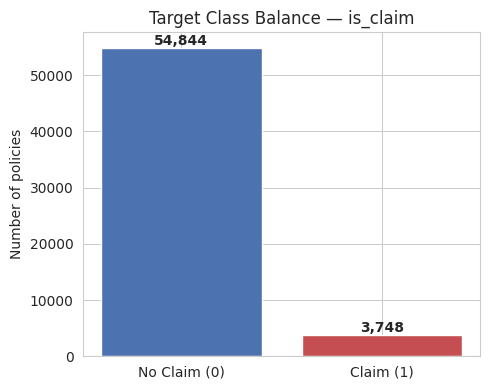


Claim rate is only 6.4% — this is a strongly imbalanced target. This will be important to account for in Stage 2 modelling (e.g. stratified split, class weighting) and is why ROC-AUC/recall are prioritised over raw accuracy (Task 1.1).


In [ ]:
# Target class balance
claim_counts = df['is_claim'].value_counts().sort_index()
claim_pct = (df['is_claim'].value_counts(normalize=True) * 100).sort_index()
summary = pd.DataFrame({'count': claim_counts, 'pct': claim_pct.round(2)})
summary.index = ['No Claim (0)', 'Claim (1)']
print(summary)

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#4C72B0', '#C44E52']
ax.bar(summary.index, summary['count'], color=colors)
for i, v in enumerate(summary['count']):
    ax.text(i, v + 500, f"{v:,}", ha='center', fontweight='bold')
ax.set_title('Target Class Balance — is_claim')
ax.set_ylabel('Number of policies')
plt.tight_layout()
plt.show()

print(f"\nClaim rate is only {claim_pct.iloc[1]:.1f}% — this is a strongly imbalanced target."
      " This will be important to account for in Stage 2 modelling (e.g. stratified split,"
      " class weighting) and is why ROC-AUC/recall are prioritised over raw accuracy (Task 1.1).")

In [ ]:
# Target Class Balance

claim_counts = df['is_claim'].value_counts().sort_index()

print("Target Class Counts:")
display(claim_counts)

claim_percentages = (
    df['is_claim']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTarget Class Percentages:")
display(claim_percentages)

# Class imbalance ratio
no_claim_count = (df['is_claim'] == 0).sum()
claim_count = (df['is_claim'] == 1).sum()

imbalance_ratio = no_claim_count / claim_count

print(
    f"\nClass Imbalance Ratio (No Claim : Claim): "
    f"{imbalance_ratio:.2f}:1"
)

Target Class Counts:


,count
is_claim,
0,54844
1,3748



Target Class Percentages:


,proportion
is_claim,
0,93.6
1,6.4



Class Imbalance Ratio (No Claim : Claim): 14.63:1


### Standardising categorical labels & fixing data-type inconsistencies

Two columns — `max_torque` and `max_power` — are stored as compound strings (e.g. `"200Nm@1750rpm"`,
`"88.50bhp@6000rpm"`) that mix a physical measurement with an RPM value inside a single text field.
These need to be split into clean numeric columns before they can be used in modelling. All the
`Yes`/`No` flag columns are also standardised and converted to proper 0/1 binary integers rather than
being left as free-text strings.

In [ ]:
str_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print("Text/categorical columns:", str_cols)

# Strip whitespace and standardise casing across all text columns
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()

Text/categorical columns: ['policy_id', 'area_cluster', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']


In [ ]:
# Parse max_torque -> torque_nm, torque_rpm
torque_extract = df['max_torque'].str.extract(r'([\d.]+)Nm@(\d+)rpm')
df['torque_nm'] = torque_extract[0].astype(float)
df['torque_rpm'] = torque_extract[1].astype(float)

# Parse max_power -> power_bhp, power_rpm
power_extract = df['max_power'].str.extract(r'([\d.]+)bhp@(\d+)rpm')
df['power_bhp'] = power_extract[0].astype(float)
df['power_rpm'] = power_extract[1].astype(float)

print(df[['max_torque', 'torque_nm', 'torque_rpm', 'max_power', 'power_bhp', 'power_rpm']].head())
print("\nAny parsing failures (NaNs introduced)?",
      df[['torque_nm', 'torque_rpm', 'power_bhp', 'power_rpm']].isnull().sum().sum())

df = df.drop(columns=['max_torque', 'max_power'])

      max_torque  torque_nm  torque_rpm         max_power  power_bhp  \
0   60Nm@3500rpm       60.0      3500.0  40.36bhp@6000rpm      40.36   
1   60Nm@3500rpm       60.0      3500.0  40.36bhp@6000rpm      40.36   
2   60Nm@3500rpm       60.0      3500.0  40.36bhp@6000rpm      40.36   
3  113Nm@4400rpm      113.0      4400.0  88.50bhp@6000rpm      88.50   
4   91Nm@4250rpm       91.0      4250.0  67.06bhp@5500rpm      67.06   

   power_rpm  
0     6000.0  
1     6000.0  
2     6000.0  
3     6000.0  
4     5500.0  

Any parsing failures (NaNs introduced)? 0


In [12]:
# --------------------------------------------------
# Detect and standardise Yes/No columns
# --------------------------------------------------

yes_no_cols = []

for col in df.select_dtypes(include=['object', 'string']).columns:

    cleaned = (
        df[col]
        .astype('string')
        .str.strip()
        .str.title()
    )

    unique_values = set(cleaned.dropna().unique())

    if unique_values.issubset({'Yes', 'No'}):
        df[col] = cleaned
        yes_no_cols.append(col)

print("Detected Yes/No columns:")
print(yes_no_cols)

Detected Yes/No columns:
['is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']


In [13]:
print("\nUnique values after standardisation:")

for col in yes_no_cols:
    print(f"{col}: {df[col].dropna().unique()}")


Unique values after standardisation:
is_esc: <StringArray>
['No', 'Yes']
Length: 2, dtype: string
is_adjustable_steering: <StringArray>
['No', 'Yes']
Length: 2, dtype: string
is_tpms: <StringArray>
['No', 'Yes']
Length: 2, dtype: string
is_parking_sensors: <StringArray>
['Yes', 'No']
Length: 2, dtype: string
is_parking_camera: <StringArray>
['No', 'Yes']
Length: 2, dtype: string
is_front_fog_lights: <StringArray>
['No', 'Yes']
Length: 2, dtype: string
is_rear_window_wiper: <StringArray>
['No', 'Yes']
Length: 2, dtype: string
is_rear_window_washer: <StringArray>
['No', 'Yes']
Length: 2, dtype: string
is_rear_window_defogger: <StringArray>
['No', 'Yes']
Length: 2, dtype: string
is_brake_assist: <StringArray>
['No', 'Yes']
Length: 2, dtype: string
is_power_door_locks: <StringArray>
['No', 'Yes']
Length: 2, dtype: string
is_central_locking: <StringArray>
['No', 'Yes']
Length: 2, dtype: string
is_power_steering: <StringArray>
['Yes', 'No']
Length: 2, dtype: string
is_driver_seat_height_adj

In [14]:
# --------------------------------------------------
# STEP 4: Extract numeric values from max_power
# and max_torque
# --------------------------------------------------

def extract_leading_number(x):
    """
    Extract the first numeric value from a string.
    Example:
    '88.50bhp@6000rpm' -> 88.50
    '113Nm@4400rpm'   -> 113.0
    """
    match = re.search(r'[\d.]+', str(x))

    if match:
        return float(match.group())

    return np.nan


# Create required engineered columns
df['max_power_bhp'] = df['max_power'].apply(extract_leading_number)

df['max_torque_nm'] = df['max_torque'].apply(extract_leading_number)

In [15]:
# Verify power and torque extraction

display(
    df[
        ['max_power', 'max_power_bhp',
         'max_torque', 'max_torque_nm']
    ].head(10)
)

,max_power,max_power_bhp,max_torque,max_torque_nm
0,40.36bhp@6000rpm,40.36,60Nm@3500rpm,60.0
1,40.36bhp@6000rpm,40.36,60Nm@3500rpm,60.0
2,40.36bhp@6000rpm,40.36,60Nm@3500rpm,60.0
3,88.50bhp@6000rpm,88.50,113Nm@4400rpm,113.0
4,67.06bhp@5500rpm,67.06,91Nm@4250rpm,91.0
5,113.45bhp@4000rpm,113.45,250Nm@2750rpm,250.0
6,88.77bhp@4000rpm,88.77,200Nm@3000rpm,200.0
7,88.50bhp@6000rpm,88.50,113Nm@4400rpm,113.0
8,113.45bhp@4000rpm,113.45,250Nm@2750rpm,250.0
9,88.50bhp@6000rpm,88.50,113Nm@4400rpm,113.0


In [16]:
print("Missing values created in max_power_bhp:",
      df['max_power_bhp'].isna().sum())

print("Missing values created in max_torque_nm:",
      df['max_torque_nm'].isna().sum())

Missing values created in max_power_bhp: 0
Missing values created in max_torque_nm: 0


In [17]:
# --------------------------------------------------
# STEP 5: Datatype Correction
# --------------------------------------------------

numeric_cols = [
    'policy_tenure',
    'age_of_car',
    'age_of_policyholder',
    'population_density',
    'make',
    'airbags',
    'displacement',
    'cylinder',
    'gear_box',
    'turning_radius',
    'length',
    'width',
    'height',
    'gross_weight',
    'ncap_rating',
    'max_power_bhp',
    'max_torque_nm',
    'is_claim'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [18]:
print(df[['max_power_bhp', 'max_torque_nm']].dtypes)

max_power_bhp    float64
max_torque_nm    float64
dtype: object


In [19]:
# --------------------------------------------------
# Check missing values after datatype conversion
# --------------------------------------------------

missing_after_conversion = df.isnull().sum()

print("Columns with missing values after conversion:")

display(
    missing_after_conversion[
        missing_after_conversion > 0
    ].sort_values(ascending=False)
)

Columns with missing values after conversion:


,0


In [20]:
# --------------------------------------------------
# Handle missing values
# Numeric  -> Median
# Categorical -> Mode
# --------------------------------------------------

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

categorical_columns = df.select_dtypes(
    include=['object', 'string']
).columns

for col in categorical_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

In [21]:
print(
    "Total missing values after imputation:",
    df.isnull().sum().sum()
)

Total missing values after imputation: 0


In [22]:
print("Final numeric datatype summary:")
display(df[numeric_cols].dtypes)

Final numeric datatype summary:


,0
policy_tenure,float64
age_of_car,float64
age_of_policyholder,float64
population_density,int64
make,int64
airbags,int64
displacement,int64
cylinder,int64
gear_box,int64
turning_radius,float64


In [25]:
# Confirm remaining categorical (nominal) columns and their cardinality
remaining_cat = df.select_dtypes(include=['object', 'string']).columns.tolist()
remaining_cat = [c for c in remaining_cat if c != 'policy_id']
for c in remaining_cat:
    print(f"{c:20s} -> {df[c].nunique()} unique values: {sorted(df[c].unique())[:10]}")

area_cluster         -> 22 unique values: ['C1', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18']
segment              -> 6 unique values: ['A', 'B1', 'B2', 'C1', 'C2', 'Utility']
model                -> 11 unique values: ['M1', 'M10', 'M11', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8']
fuel_type            -> 3 unique values: ['CNG', 'Diesel', 'Petrol']
max_torque           -> 9 unique values: ['113Nm@4400rpm', '170Nm@4000rpm', '200Nm@1750rpm', '200Nm@3000rpm', '250Nm@2750rpm', '60Nm@3500rpm', '82.1Nm@3400rpm', '85Nm@3000rpm', '91Nm@4250rpm']
max_power            -> 9 unique values: ['113.45bhp@4000rpm', '118.36bhp@5500rpm', '40.36bhp@6000rpm', '55.92bhp@5300rpm', '61.68bhp@6000rpm', '67.06bhp@5500rpm', '88.50bhp@6000rpm', '88.77bhp@4000rpm', '97.89bhp@3600rpm']
engine_type          -> 11 unique values: ['1.0 SCe', '1.2 L K Series Engine', '1.2 L K12N Dualjet', '1.5 L U2 CRDi', '1.5 Turbocharged Revotorq', '1.5 Turbocharged Revotron', 'F8D Petrol Engine', 'G12B', 'K Series 

In [23]:
# --------------------------------------------------
# STEP 6: Encode Yes/No columns as 0/1
# --------------------------------------------------

for col in yes_no_cols:
    df[col] = df[col].map({
        'Yes': 1,
        'No': 0
    }).astype('int64')

print("Yes/No columns encoded successfully:")
print(yes_no_cols)

Yes/No columns encoded successfully:
['is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']


In [24]:
# Verify encoded values

for col in yes_no_cols:
    print(f"{col}: {sorted(df[col].dropna().unique())}")

is_esc: [np.int64(0), np.int64(1)]
is_adjustable_steering: [np.int64(0), np.int64(1)]
is_tpms: [np.int64(0), np.int64(1)]
is_parking_sensors: [np.int64(0), np.int64(1)]
is_parking_camera: [np.int64(0), np.int64(1)]
is_front_fog_lights: [np.int64(0), np.int64(1)]
is_rear_window_wiper: [np.int64(0), np.int64(1)]
is_rear_window_washer: [np.int64(0), np.int64(1)]
is_rear_window_defogger: [np.int64(0), np.int64(1)]
is_brake_assist: [np.int64(0), np.int64(1)]
is_power_door_locks: [np.int64(0), np.int64(1)]
is_central_locking: [np.int64(0), np.int64(1)]
is_power_steering: [np.int64(0), np.int64(1)]
is_driver_seat_height_adjustable: [np.int64(0), np.int64(1)]
is_day_night_rear_view_mirror: [np.int64(0), np.int64(1)]
is_ecw: [np.int64(0), np.int64(1)]
is_speed_alert: [np.int64(0), np.int64(1)]


In [26]:
print(yes_no_cols)

['is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']


In [27]:
# --------------------------------------------------
# STEP 7: One-Hot Encoding
# --------------------------------------------------

one_hot_cols = [
    'area_cluster',
    'segment',
    'fuel_type',
    'engine_type',
    'rear_brakes_type',
    'transmission_type',
    'steering_type'
]

# Check that all required columns exist
missing_cols = [
    col for col in one_hot_cols
    if col not in df.columns
]

if missing_cols:
    print("Missing required categorical columns:", missing_cols)
else:
    print("All required categorical columns are present.")
    print(one_hot_cols)

All required categorical columns are present.
['area_cluster', 'segment', 'fuel_type', 'engine_type', 'rear_brakes_type', 'transmission_type', 'steering_type']


In [28]:
# Apply one-hot encoding
df = pd.get_dummies(
    df,
    columns=one_hot_cols,
    drop_first=False
)

print("One-hot encoding completed.")
print(f"New dataset shape: {df.shape}")

One-hot encoding completed.
New dataset shape: (58592, 88)


In [29]:
drop_first=False

In [32]:
# Check new dataset shape
print(f"New dataset shape: {df.shape}")

New dataset shape: (58592, 88)


In [33]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.head())

Rows: 58592
Columns: 88
  policy_id  policy_tenure  age_of_car  age_of_policyholder  \
0   ID00001       0.515874        0.05             0.644231   
1   ID00002       0.672619        0.02             0.375000   
2   ID00003       0.841110        0.02             0.384615   
3   ID00004       0.900277        0.11             0.432692   
4   ID00005       0.596403        0.11             0.634615   

   population_density  make model     max_torque         max_power  airbags  \
0                4990     1    M1   60Nm@3500rpm  40.36bhp@6000rpm        2   
1               27003     1    M1   60Nm@3500rpm  40.36bhp@6000rpm        2   
2                4076     1    M1   60Nm@3500rpm  40.36bhp@6000rpm        2   
3               21622     1    M2  113Nm@4400rpm  88.50bhp@6000rpm        2   
4               34738     2    M3   91Nm@4250rpm  67.06bhp@5500rpm        2   

   is_esc  is_adjustable_steering  is_tpms  is_parking_sensors  \
0       0                       0        0              

In [30]:
# Display newly created one-hot encoded columns

encoded_cols = [
    col for col in df.columns
    if any(col.startswith(prefix + '_') for prefix in one_hot_cols)
]

print("One-hot encoded columns:")
print(encoded_cols)

One-hot encoded columns:
['area_cluster_C1', 'area_cluster_C10', 'area_cluster_C11', 'area_cluster_C12', 'area_cluster_C13', 'area_cluster_C14', 'area_cluster_C15', 'area_cluster_C16', 'area_cluster_C17', 'area_cluster_C18', 'area_cluster_C19', 'area_cluster_C2', 'area_cluster_C20', 'area_cluster_C21', 'area_cluster_C22', 'area_cluster_C3', 'area_cluster_C4', 'area_cluster_C5', 'area_cluster_C6', 'area_cluster_C7', 'area_cluster_C8', 'area_cluster_C9', 'segment_A', 'segment_B1', 'segment_B2', 'segment_C1', 'segment_C2', 'segment_Utility', 'fuel_type_CNG', 'fuel_type_Diesel', 'fuel_type_Petrol', 'engine_type_1.0 SCe', 'engine_type_1.2 L K Series Engine', 'engine_type_1.2 L K12N Dualjet', 'engine_type_1.5 L U2 CRDi', 'engine_type_1.5 Turbocharged Revotorq', 'engine_type_1.5 Turbocharged Revotron', 'engine_type_F8D Petrol Engine', 'engine_type_G12B', 'engine_type_K Series Dual jet', 'engine_type_K10C', 'engine_type_i-DTEC', 'rear_brakes_type_Disc', 'rear_brakes_type_Drum', 'transmission_t

In [31]:
remaining_original_cats = [
    col for col in one_hot_cols
    if col in df.columns
]

print("Original categorical columns still present:")
print(remaining_original_cats)

Original categorical columns still present:
[]


In [34]:
# --------------------------------------------------
# STEP 8: IQR Outlier Capping
# --------------------------------------------------

# Identify numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude target variable
numeric_features = [
    col for col in numeric_cols
    if col != 'is_claim'
]

# Keep only continuous numeric variables
continuous_cols = []

for col in numeric_features:
    unique_values = df[col].nunique(dropna=True)

    # Exclude binary 0/1 columns
    if unique_values > 2:
        continuous_cols.append(col)

print("Continuous numeric columns selected for IQR capping:")
print(continuous_cols)

Continuous numeric columns selected for IQR capping:
['policy_tenure', 'age_of_car', 'age_of_policyholder', 'population_density', 'make', 'airbags', 'displacement', 'turning_radius', 'length', 'width', 'height', 'gross_weight', 'ncap_rating', 'max_power_bhp', 'max_torque_nm']


In [35]:
# Apply IQR capping

for col in continuous_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("IQR outlier capping completed.")

IQR outlier capping completed.


In [37]:
# Verify no missing values were introduced

print(
    "Total missing values after IQR capping:",
    df.isnull().sum().sum()
)

print("Current dataset shape:", df.shape)

Total missing values after IQR capping: 0
Current dataset shape: (58592, 88)


### Outlier detection & treatment

Outliers are checked on the key continuous numeric features using the IQR rule. Rather than
dropping rows (which would shrink an already small claims class further), values beyond the IQR
fences are **capped (winsorised)** at the fence value, which preserves the row while limiting the
influence of extreme values on the model.

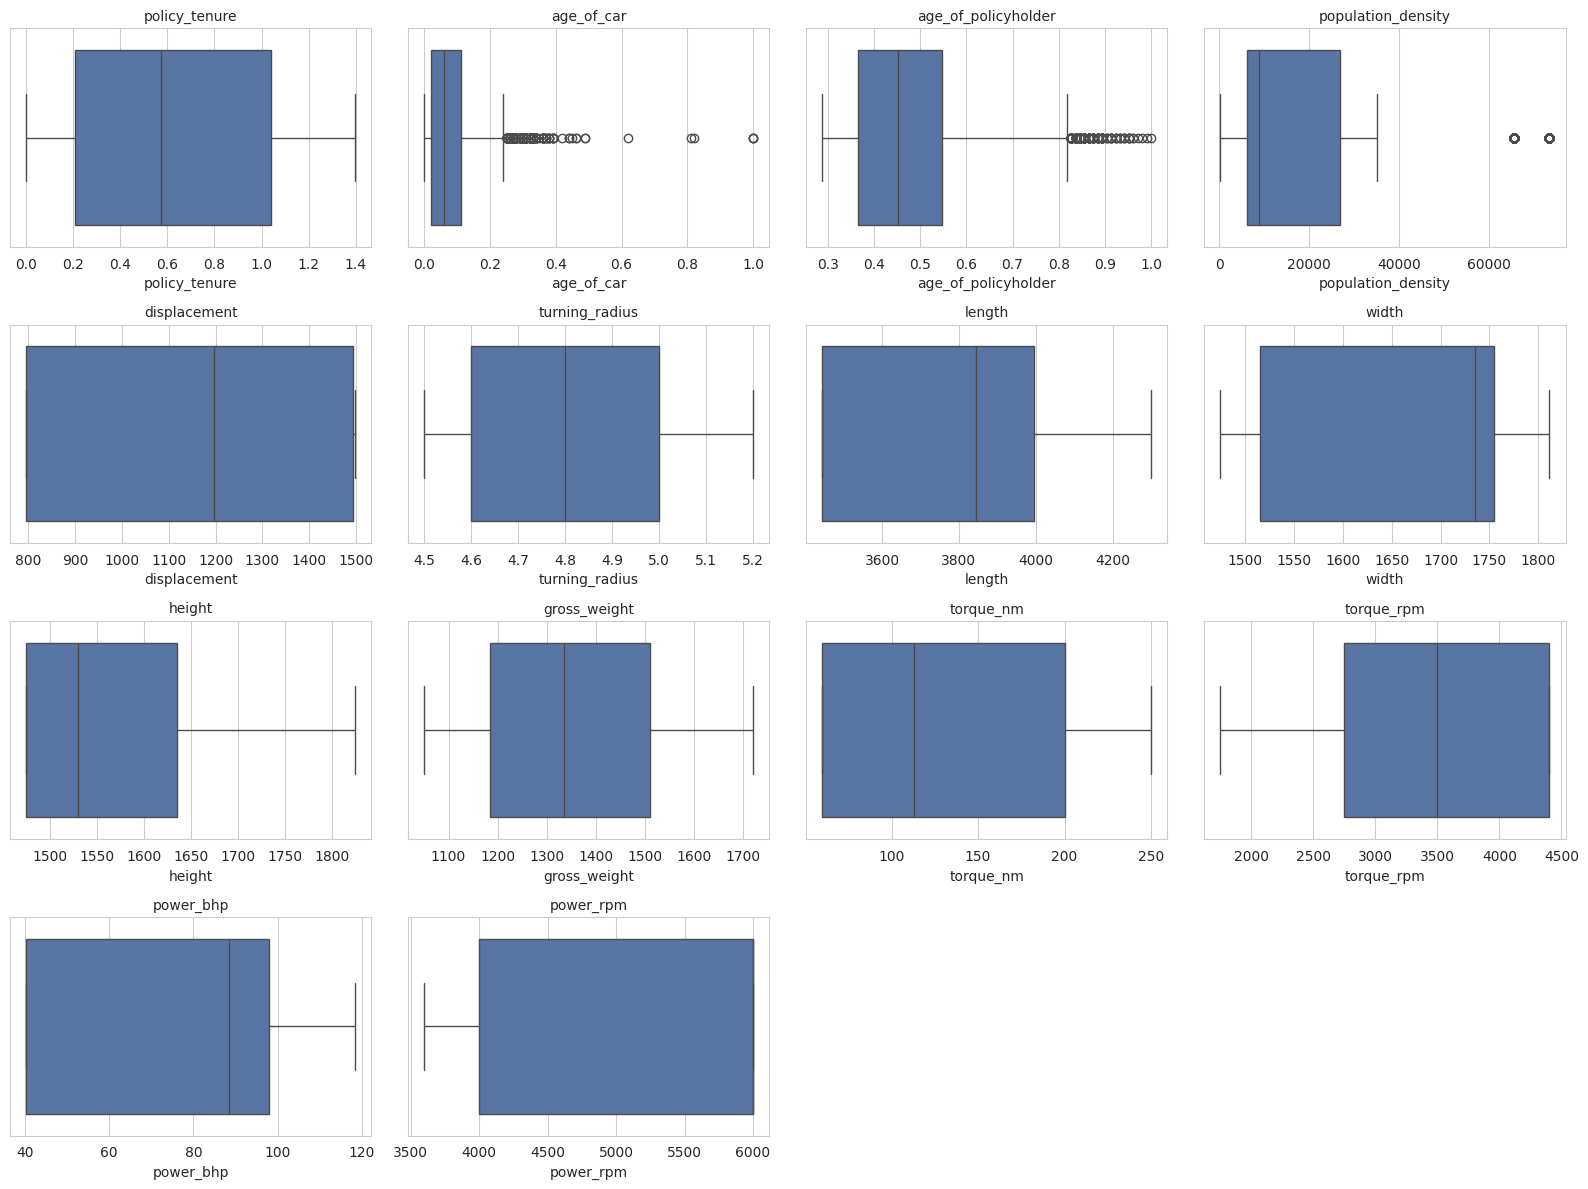

In [ ]:
continuous_cols = ['policy_tenure', 'age_of_car', 'age_of_policyholder',
                   'population_density', 'displacement', 'turning_radius',
                   'length', 'width', 'height', 'gross_weight',
                   'torque_nm', 'torque_rpm', 'power_bhp', 'power_rpm']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, c in enumerate(continuous_cols):
    sns.boxplot(x=df[c], ax=axes[i], color='#4C72B0')
    axes[i].set_title(c, fontsize=10)
for j in range(len(continuous_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def cap_outliers_iqr(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    n_out = ((series < lower) | (series > upper)).sum()
    return series.clip(lower, upper), n_out, lower, upper

outlier_report = []
for c in continuous_cols:
    df[c], n_out, lo, hi = cap_outliers_iqr(df[c])
    outlier_report.append({'feature': c, 'outliers_capped': n_out,
                            'lower_fence': round(lo, 2), 'upper_fence': round(hi, 2)})

outlier_report_df = pd.DataFrame(outlier_report)
print(outlier_report_df.to_string(index=False))

            feature  outliers_capped  lower_fence  upper_fence
      policy_tenure                0        -1.03         2.28
         age_of_car              269        -0.12         0.24
age_of_policyholder              221         0.09         0.82
 population_density             3647    -25224.50     58339.50
       displacement                0      -249.50      2538.50
     turning_radius                0         4.00         5.60
             length                0      2620.00      4820.00
              width                0      1155.00      2115.00
             height                0      1235.00      1875.00
       gross_weight                0       697.50      1997.50
          torque_nm                0      -150.00       410.00
         torque_rpm                0       275.00      6875.00
          power_bhp                0       -45.94       184.18
          power_rpm                0      1000.00      9000.00


### Skewness check & transformation

Right-skewed numeric features (e.g. `population_density`, which ranges from a few hundred to tens
of thousands of people/sq.km) can distort distance- and coefficient-based models. Features with
absolute skewness above 1 are log-transformed using `log1p` (safe for zero values).

In [ ]:
skew_before = df[continuous_cols].skew().sort_values(ascending=False)
print("Skewness before transform:")
print(skew_before.round(2))

skewed_cols = skew_before[skew_before.abs() > 1].index.tolist()
print(f"\nColumns to log-transform (|skew| > 1): {skewed_cols}")

for c in skewed_cols:
    df[f'{c}_log'] = np.log1p(df[c])

skew_after = df[[f'{c}_log' for c in skewed_cols]].skew()
print("\nSkewness after log1p transform:")
print(skew_after.round(2))

Skewness before transform:
population_density     1.16
height                 1.04
torque_nm              0.67
age_of_car             0.65
age_of_policyholder    0.62
gross_weight           0.55
turning_radius         0.42
length                 0.15
policy_tenure          0.05
displacement          -0.11
power_bhp             -0.24
torque_rpm            -0.30
width                 -0.49
power_rpm             -0.76
dtype: float64

Columns to log-transform (|skew| > 1): ['population_density', 'height']

Skewness after log1p transform:
population_density_log   -0.57
height_log                0.92
dtype: float64


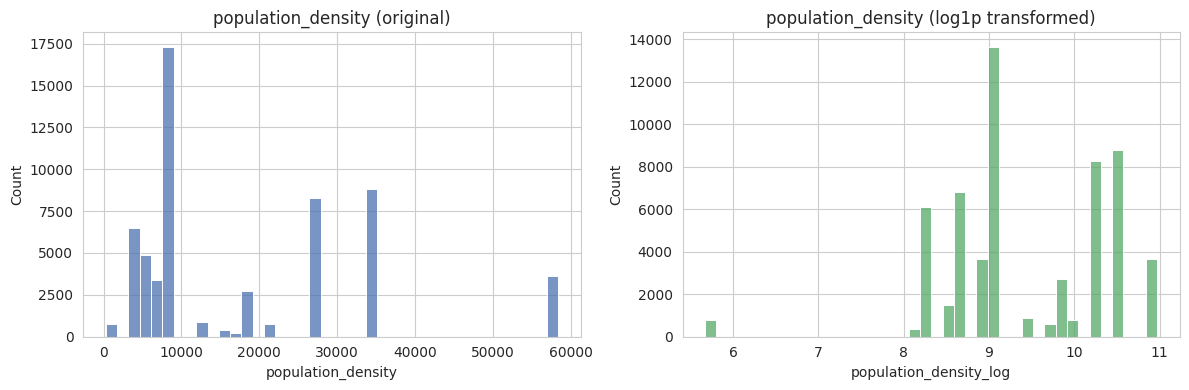

In [ ]:
# Visual check: population_density before vs after transform
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['population_density'], bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('population_density (original)')
sns.histplot(df['population_density_log'], bins=40, ax=axes[1], color='#55A868')
axes[1].set_title('population_density (log1p transformed)')
plt.tight_layout()
plt.show()

### Categorical encoding

- **Low-cardinality nominal columns** (`segment`, `fuel_type`, `rear_brakes_type`,
  `transmission_type`, `steering_type`, `make`) → **one-hot encoded**, since there is no natural
  order and the number of resulting dummy columns stays manageable.
- **High-cardinality nominal columns** (`area_cluster`, `model`, `engine_type` — 11–22 unique
  values each) → **frequency encoded** (replaced with how often each category appears in the
  data), which avoids an explosion of sparse dummy columns while still giving the model a usable
  numeric signal.
- **`ncap_rating`** is already an ordinal 0–5 safety rating, so it is kept as-is (no encoding
  needed).

In [ ]:
low_card_cols = ['segment', 'fuel_type', 'rear_brakes_type', 'transmission_type',
                 'steering_type', 'make']
high_card_cols = ['area_cluster', 'model', 'engine_type']

# One-hot encode low-cardinality columns
df_encoded = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

# Frequency encode high-cardinality columns
for c in high_card_cols:
    freq_map = df_encoded[c].value_counts(normalize=True)
    df_encoded[f'{c}_freq'] = df_encoded[c].map(freq_map)
df_encoded = df_encoded.drop(columns=high_card_cols)

print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()

Shape after encoding: (58592, 57)


,policy_id,policy_tenure,age_of_car,age_of_policyholder,population_density,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim,torque_nm,torque_rpm,power_bhp,power_rpm,population_density_log,height_log,segment_B1,segment_B2,segment_C1,segment_C2,segment_Utility,fuel_type_Diesel,fuel_type_Petrol,rear_brakes_type_Drum,transmission_type_Manual,steering_type_Manual,steering_type_Power,make_2,make_3,make_4,make_5,area_cluster_freq,model_freq,engine_type_freq
0,ID00001,0.515874,0.05,0.644231,4990.0,2,0,0,0,1,0,796,3,5,4.6,3445,1515,1475,1185,0,0,0,0,0,0,0,1,0,0,0,1,0,0,60.0,3500.0,40.36,6000.0,8.515392,7.297091,False,False,False,False,False,False,False,True,True,False,True,False,False,False,False,0.025055,0.255120,0.255120
1,ID00002,0.672619,0.02,0.375000,27003.0,2,0,0,0,1,0,796,3,5,4.6,3445,1515,1475,1185,0,0,0,0,0,0,0,1,0,0,0,1,0,0,60.0,3500.0,40.36,6000.0,10.203740,7.297091,False,False,False,False,False,False,False,True,True,False,True,False,False,False,False,0.125307,0.255120,0.255120
2,ID00003,0.841110,0.02,0.384615,4076.0,2,0,0,0,1,0,796,3,5,4.6,3445,1515,1475,1185,0,0,0,0,0,0,0,1,0,0,0,1,0,0,60.0,3500.0,40.36,6000.0,8.313117,7.297091,False,False,False,False,False,False,False,True,True,False,True,False,False,False,False,0.104127,0.255120,0.255120
3,ID00004,0.900277,0.11,0.432692,21622.0,2,1,1,0,1,1,1197,4,5,4.8,3995,1735,1515,1335,1,0,0,1,1,1,1,1,1,1,1,1,2,0,113.0,4400.0,88.50,6000.0,9.981513,7.323831,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,0.011350,0.018433,0.018433
4,ID00005,0.596403,0.11,0.634615,34738.0,2,0,0,0,0,1,999,3,5,5.0,3731,1579,1490,1155,0,0,0,0,0,1,1,1,0,1,1,1,2,0,91.0,4250.0,67.06,5500.0,10.455618,7.307202,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,0.119112,0.040500,0.040500


In [ ]:
df = df_encoded
print("Cleaning complete. Final pre-feature-engineering shape:", df.shape)

Cleaning complete. Final pre-feature-engineering shape: (58592, 57)


## Task 1.3 — Exploratory Data Analysis

### Univariate Analysis
Distributions of key numeric variables: policyholder age, vehicle age, population density and
policy tenure.

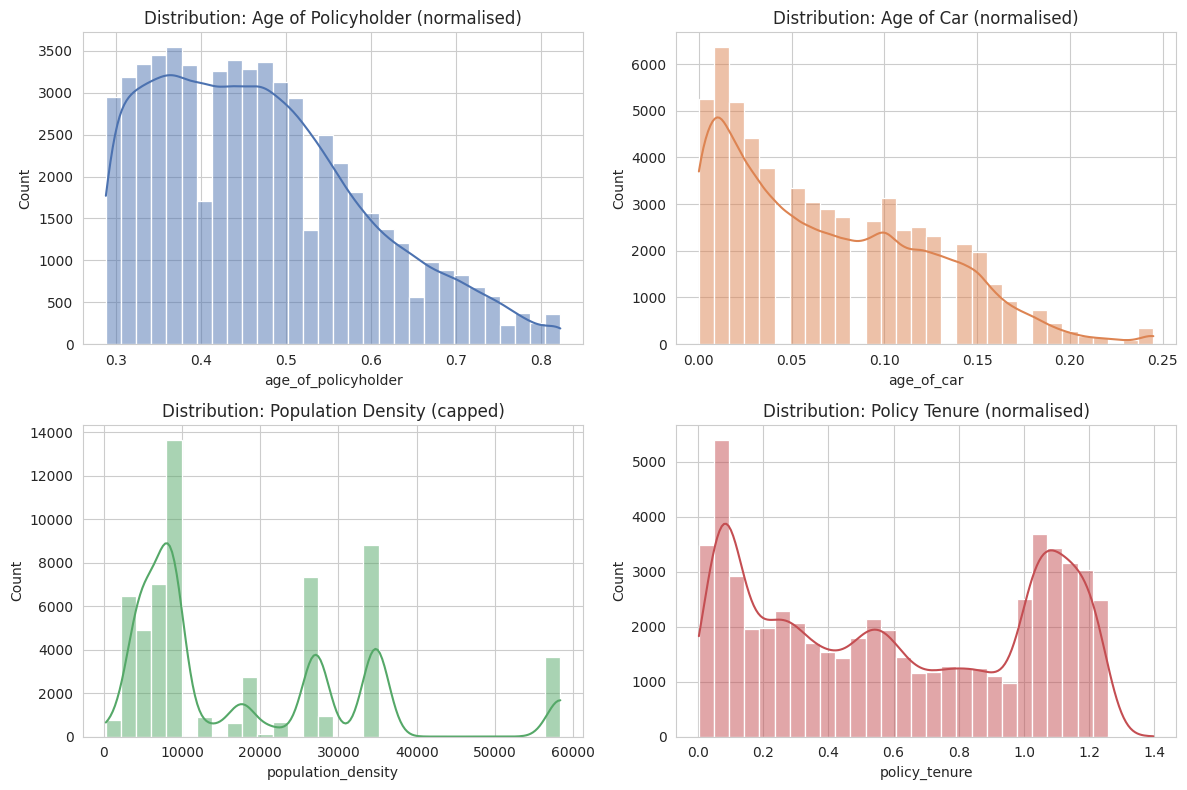

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['age_of_policyholder'], bins=30, kde=True, ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Distribution: Age of Policyholder (normalised)')

sns.histplot(df['age_of_car'], bins=30, kde=True, ax=axes[0, 1], color='#DD8452')
axes[0, 1].set_title('Distribution: Age of Car (normalised)')

sns.histplot(df['population_density'], bins=30, kde=True, ax=axes[1, 0], color='#55A868')
axes[1, 0].set_title('Distribution: Population Density (capped)')

sns.histplot(df['policy_tenure'], bins=30, kde=True, ax=axes[1, 1], color='#C44E52')
axes[1, 1].set_title('Distribution: Policy Tenure (normalised)')

plt.tight_layout()
plt.show()

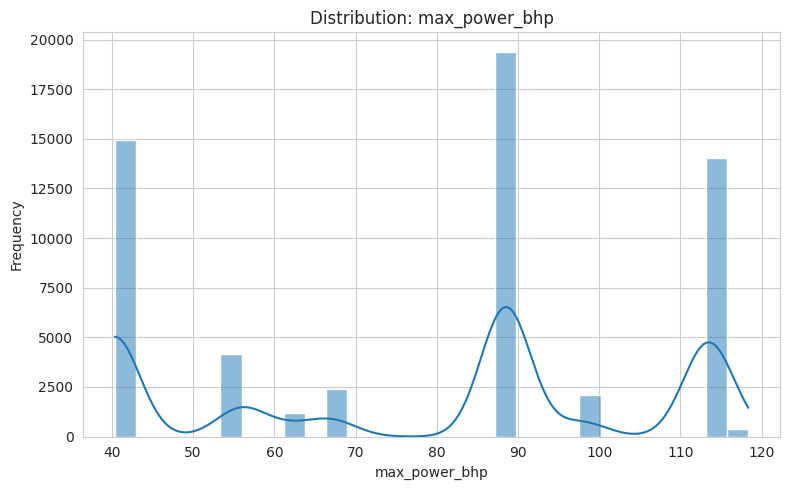

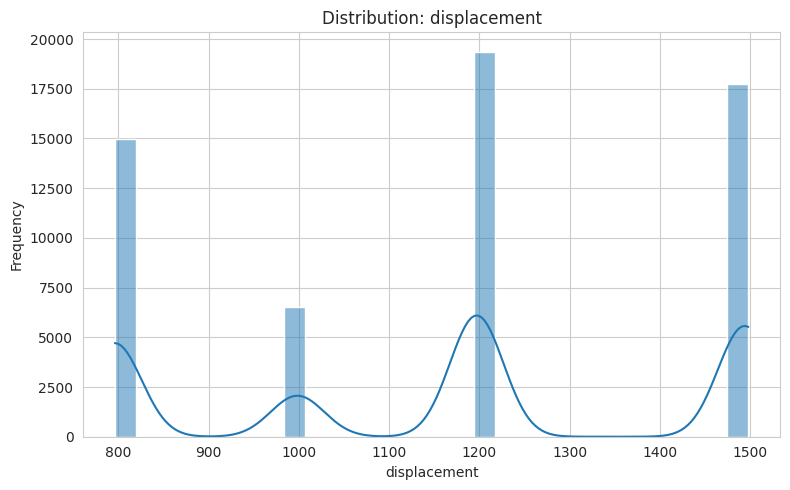

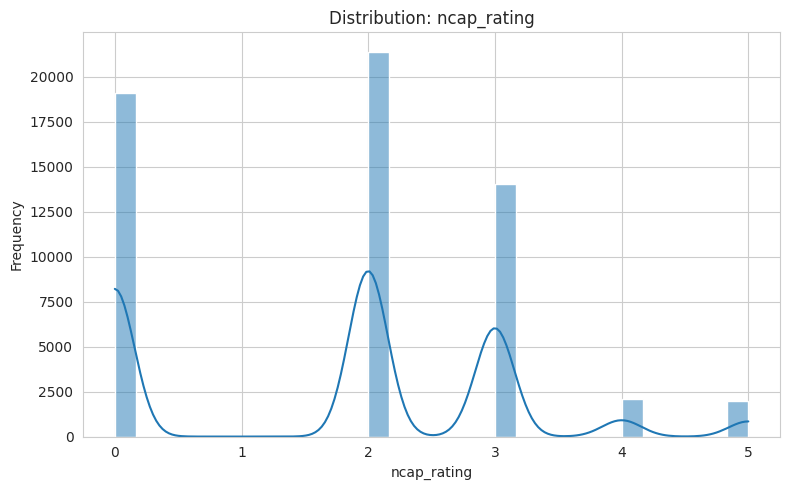

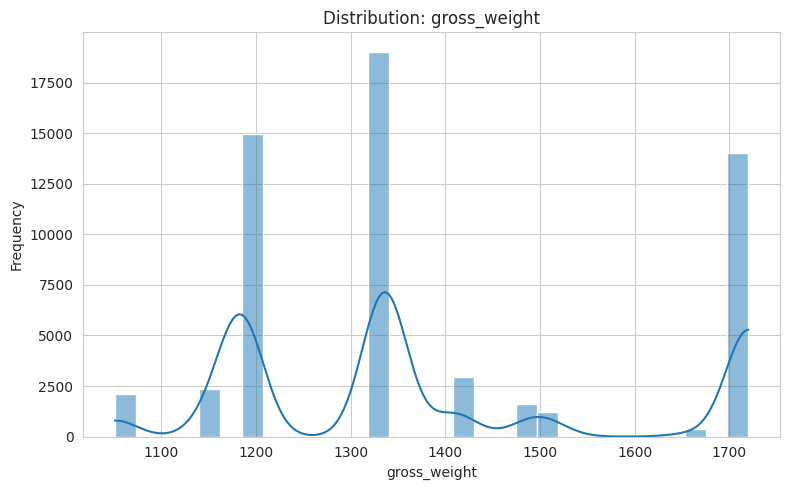

In [38]:
# Additional 4 required numerical distributions

additional_numeric_cols = [
    'max_power_bhp',
    'displacement',
    'ncap_rating',
    'gross_weight'
]

for col in additional_numeric_cols:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )

    plt.title(f'Distribution: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [39]:
# Check remaining categorical columns

remaining_categorical = df.select_dtypes(
    include=['object', 'string']
).columns.tolist()

print("Remaining categorical columns:")
print(remaining_categorical)

Remaining categorical columns:
['policy_id', 'model', 'max_torque', 'max_power']


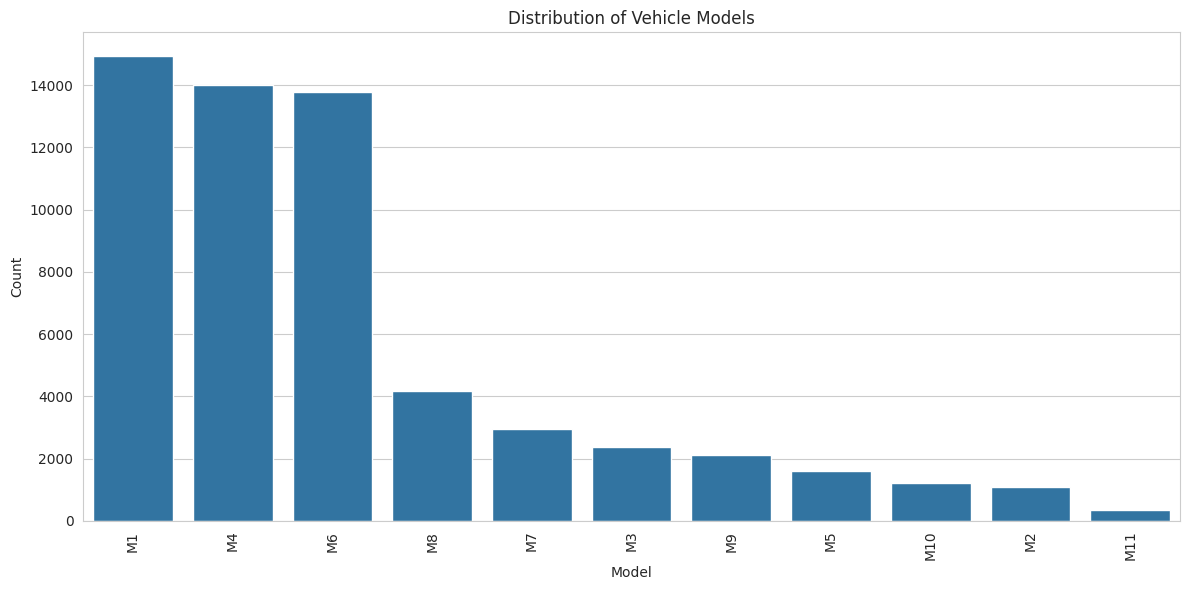

In [40]:
# --------------------------------------------------
# STEP 9B: Categorical Distribution
# --------------------------------------------------

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='model',
    order=df['model'].value_counts().index
)

plt.title('Distribution of Vehicle Models')
plt.xlabel('Model')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

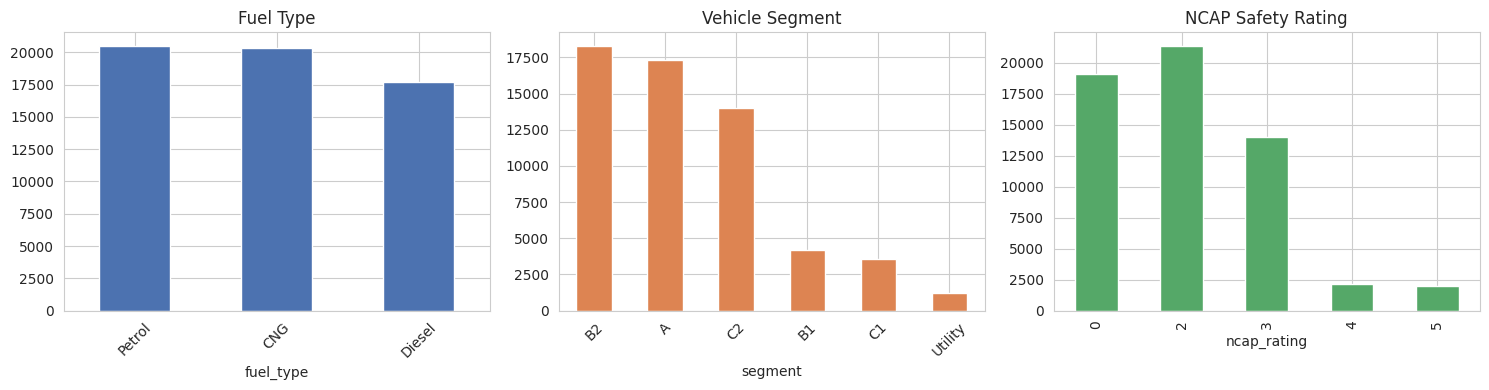

In [ ]:
# Univariate: key categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_orig = pd.read_csv('dataset.csv')
df_orig['fuel_type'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Fuel Type')
axes[0].tick_params(axis='x', rotation=45)

df_orig['segment'].value_counts().plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Vehicle Segment')
axes[1].tick_params(axis='x', rotation=45)

df['ncap_rating'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('NCAP Safety Rating')

plt.tight_layout()
plt.show()

In [41]:
# --------------------------------------------------
# STEP 10: Bivariate Analysis
# Claim Rate across Quantile Bins
# --------------------------------------------------

def claim_rate_by_quantile(df, column, q=5):

    temp = df[[column, 'is_claim']].copy()

    # Create 5 quantile bins
    temp['quantile_bin'] = pd.qcut(
        temp[column],
        q=q,
        duplicates='drop'
    )

    # Calculate claim rate
    result = (
        temp.groupby('quantile_bin', observed=True)['is_claim']
        .mean()
        .reset_index()
    )

    result['claim_rate'] = result['is_claim'] * 100

    return result[['quantile_bin', 'claim_rate']]

In [42]:
age_car_claim_rate = claim_rate_by_quantile(
    df,
    'age_of_car'
)

display(age_car_claim_rate)

,quantile_bin,claim_rate
0,"(-0.001, 0.02]",6.943122
1,"(0.02, 0.04]",6.358523
2,"(0.04, 0.08]",6.759344
3,"(0.08, 0.12]",6.542841
4,"(0.12, 0.245]",5.037228


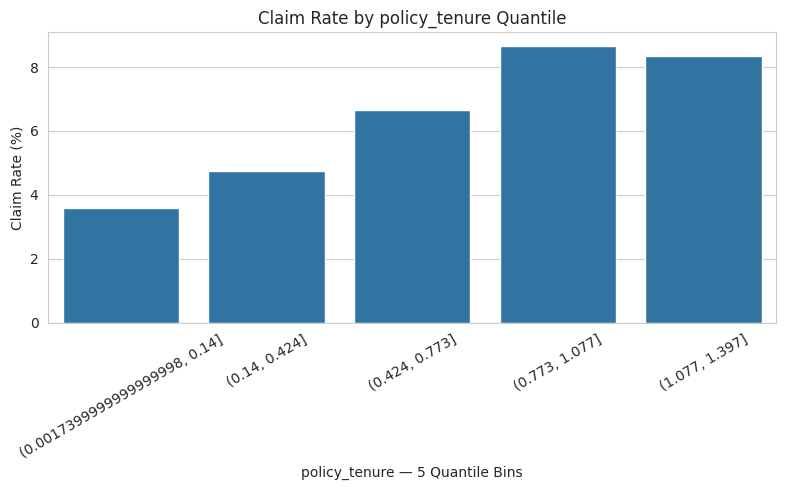

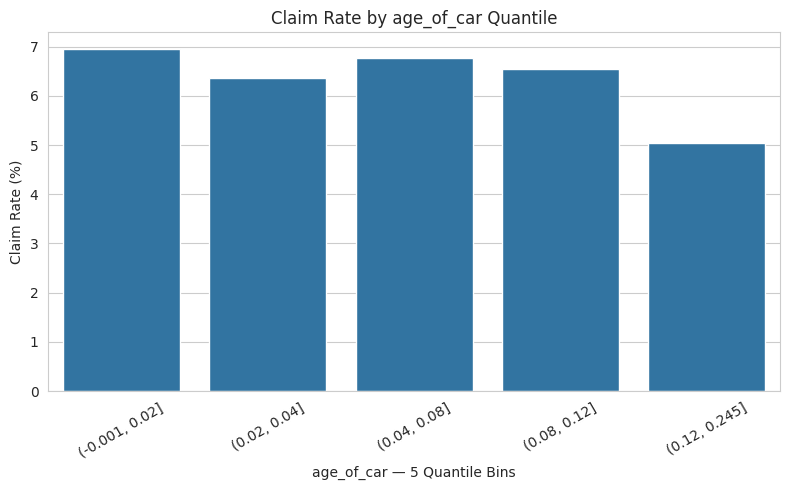

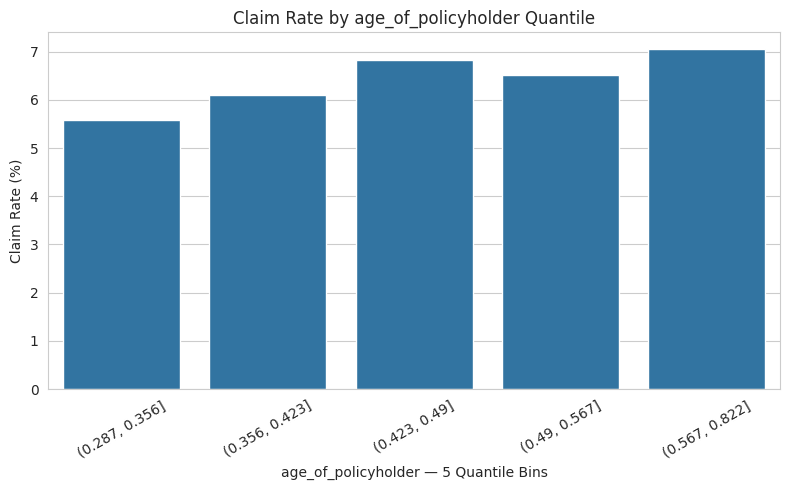

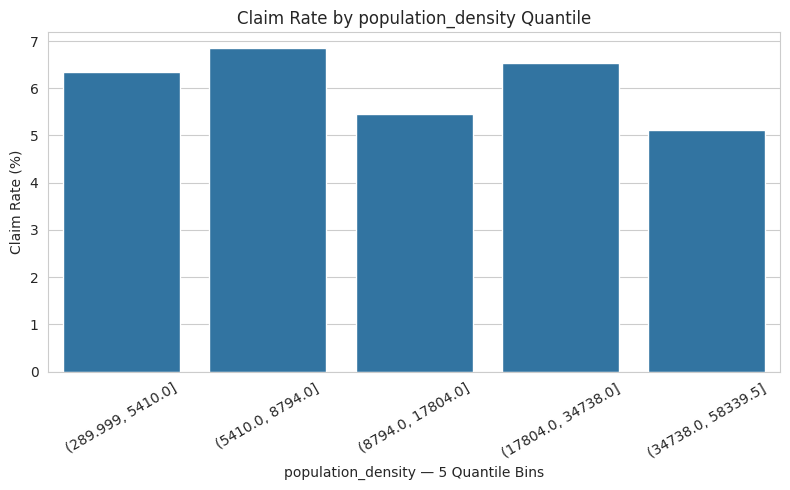

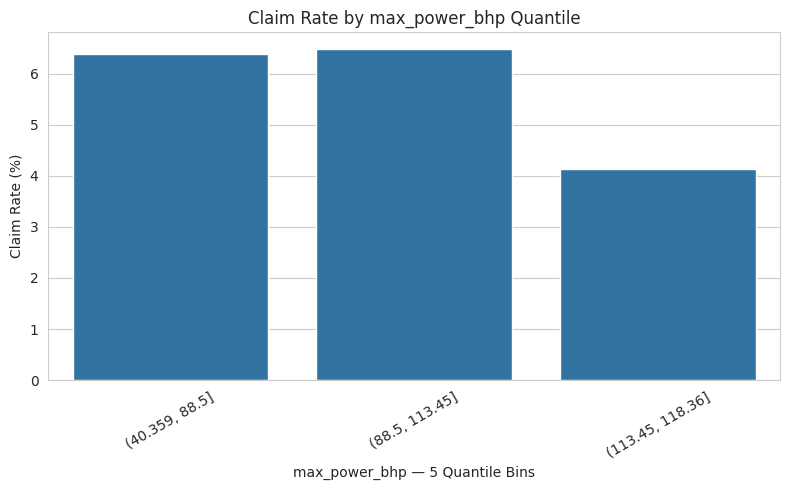

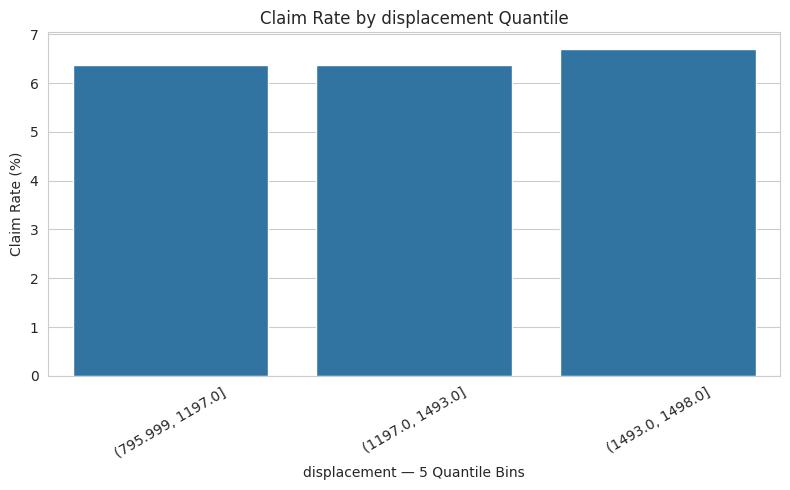

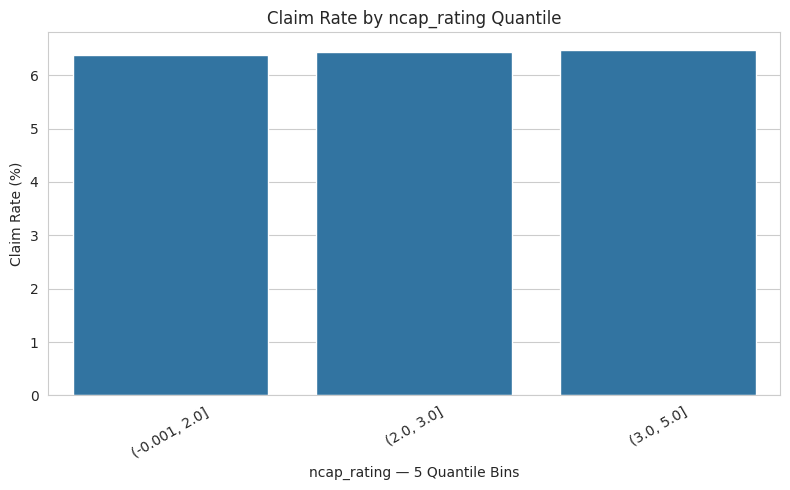

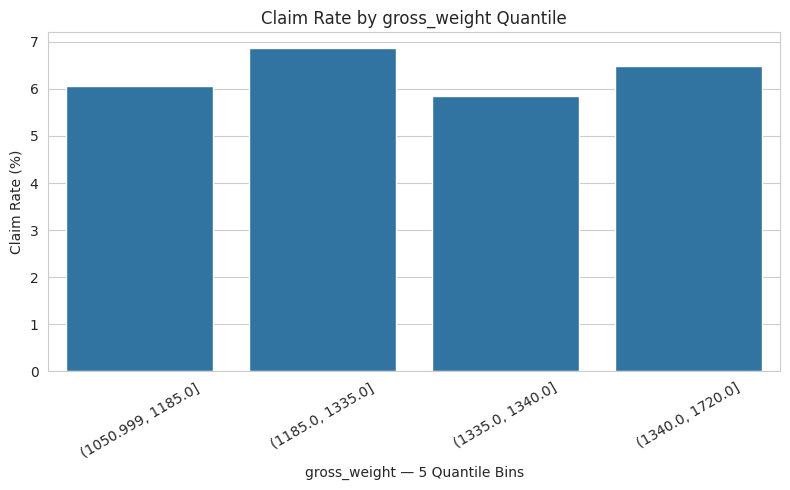

In [43]:
# --------------------------------------------------
# Claim Rate across 5 Quantile Bins
# --------------------------------------------------

bivariate_cols = [
    'policy_tenure',
    'age_of_car',
    'age_of_policyholder',
    'population_density',
    'max_power_bhp',
    'displacement',
    'ncap_rating',
    'gross_weight'
]

for col in bivariate_cols:

    result = claim_rate_by_quantile(df, col, q=5)

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=result,
        x='quantile_bin',
        y='claim_rate'
    )

    plt.title(f'Claim Rate by {col} Quantile')
    plt.xlabel(f'{col} — 5 Quantile Bins')
    plt.ylabel('Claim Rate (%)')
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

### Bivariate Analysis
Relationship between the target (`is_claim`) and key predictors: vehicle age, population density,
safety equipment (airbags), NCAP rating, fuel type and vehicle segment.

/tmp/ipykernel_625/3655450560.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_claim', y='age_of_car', data=df, ax=axes[0, 0], palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_625/3655450560.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['No Claim', 'Claim'])
/tmp/ipykernel_625/3655450560.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_claim', y='population_density', data=df, ax=axes[0, 1], palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_625/3655450560.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks()

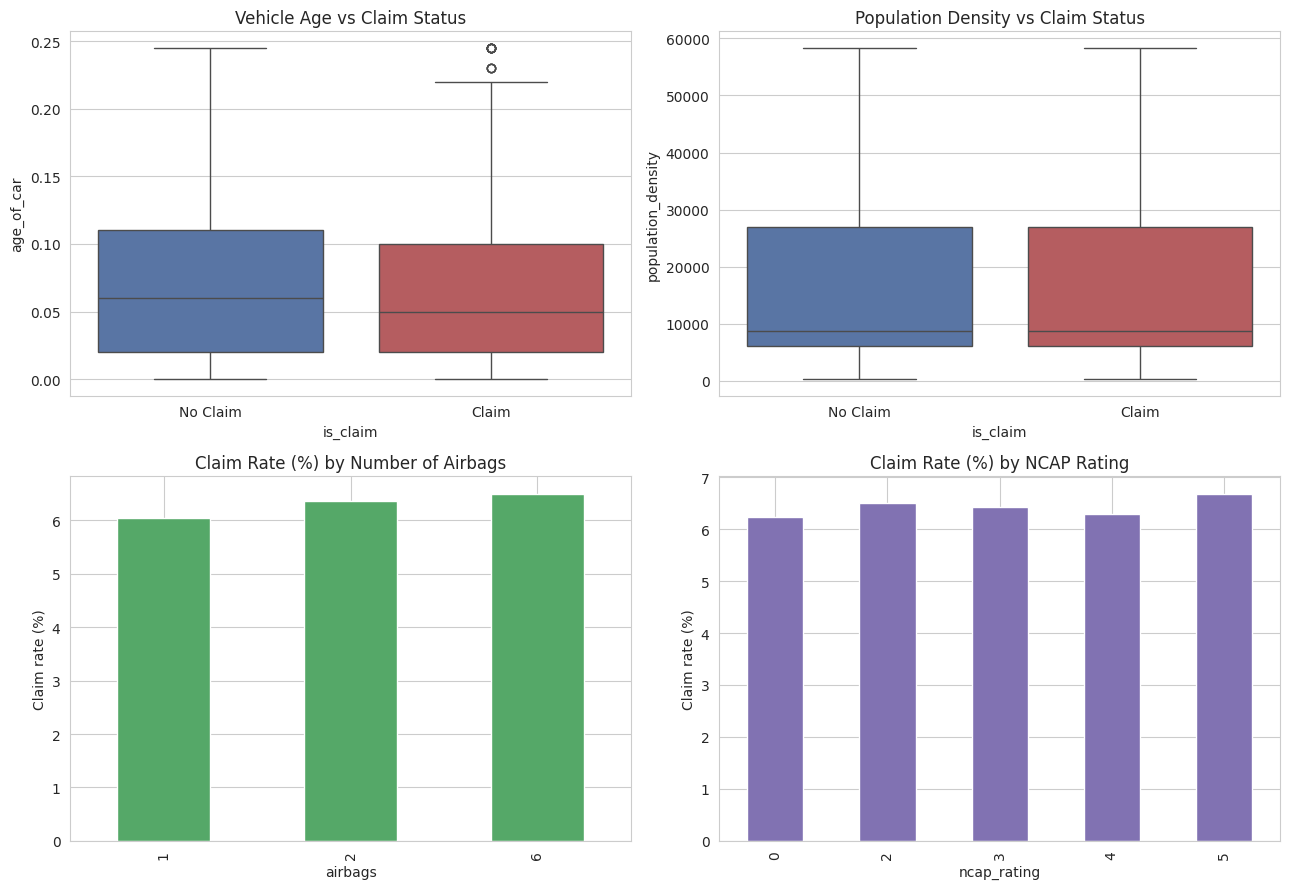

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.boxplot(x='is_claim', y='age_of_car', data=df, ax=axes[0, 0], palette=['#4C72B0', '#C44E52'])
axes[0, 0].set_title('Vehicle Age vs Claim Status')
axes[0, 0].set_xticklabels(['No Claim', 'Claim'])

sns.boxplot(x='is_claim', y='population_density', data=df, ax=axes[0, 1], palette=['#4C72B0', '#C44E52'])
axes[0, 1].set_title('Population Density vs Claim Status')
axes[0, 1].set_xticklabels(['No Claim', 'Claim'])

airbag_claim_rate = df.groupby('airbags')['is_claim'].mean() * 100
airbag_claim_rate.plot(kind='bar', ax=axes[1, 0], color='#55A868')
axes[1, 0].set_title('Claim Rate (%) by Number of Airbags')
axes[1, 0].set_ylabel('Claim rate (%)')

ncap_claim_rate = df.groupby('ncap_rating')['is_claim'].mean() * 100
ncap_claim_rate.plot(kind='bar', ax=axes[1, 1], color='#8172B2')
axes[1, 1].set_title('Claim Rate (%) by NCAP Rating')
axes[1, 1].set_ylabel('Claim rate (%)')

plt.tight_layout()
plt.show()

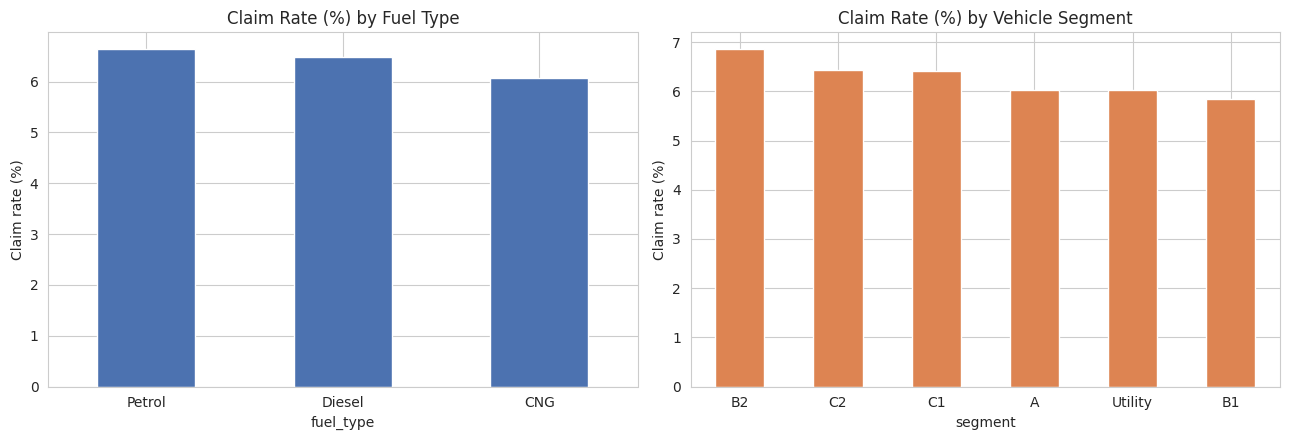

Overall claim rate: 6.4 %

Claim rate by fuel type:
 fuel_type
CNG       6.07
Diesel    6.49
Petrol    6.64
Name: is_claim, dtype: float64

Claim rate by segment:
 segment
A          6.04
B1         5.85
B2         6.86
C1         6.41
C2         6.43
Utility    6.04
Name: is_claim, dtype: float64


In [ ]:
# Claim rate by fuel type and vehicle segment (using original labels for readability)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

fuel_claim = df_orig.assign(is_claim=df['is_claim']).groupby('fuel_type')['is_claim'].mean() * 100
fuel_claim.sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Claim Rate (%) by Fuel Type')
axes[0].set_ylabel('Claim rate (%)')
axes[0].tick_params(axis='x', rotation=0)

segment_claim = df_orig.assign(is_claim=df['is_claim']).groupby('segment')['is_claim'].mean() * 100
segment_claim.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Claim Rate (%) by Vehicle Segment')
axes[1].set_ylabel('Claim rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Overall claim rate:", round(df['is_claim'].mean() * 100, 2), "%")
print("\nClaim rate by fuel type:\n", fuel_claim.round(2))
print("\nClaim rate by segment:\n", segment_claim.round(2))

**Reading the patterns against the Task 1.1 business questions:**
- Claim rate differences across airbag count, NCAP rating, fuel type and segment are visibly small
  in this dataset — no single feature shows a dramatic claim-rate split on its own, which suggests
  the signal here is likely **multivariate** (a combination of vehicle + policyholder + area
  attributes) rather than driven by any one variable. This supports framing the modelling stage
  around a multi-feature model rather than a simple univariate risk rule.
- This directly informs Business Question 3 (risk segmentation): a composite score across several
  engineered features (built next in Task 1.4) is likely to separate risk better than any single
  raw column.

In [44]:
# --------------------------------------------------
# STEP 11: Correlation Analysis
# --------------------------------------------------

# Select numeric columns
correlation_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Number of numeric columns:", len(correlation_cols))
print("\nNumeric columns:")
print(correlation_cols)

Number of numeric columns: 35

Numeric columns:
['policy_tenure', 'age_of_car', 'age_of_policyholder', 'population_density', 'make', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'displacement', 'cylinder', 'gear_box', 'turning_radius', 'length', 'width', 'height', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert', 'ncap_rating', 'is_claim', 'max_power_bhp', 'max_torque_nm']


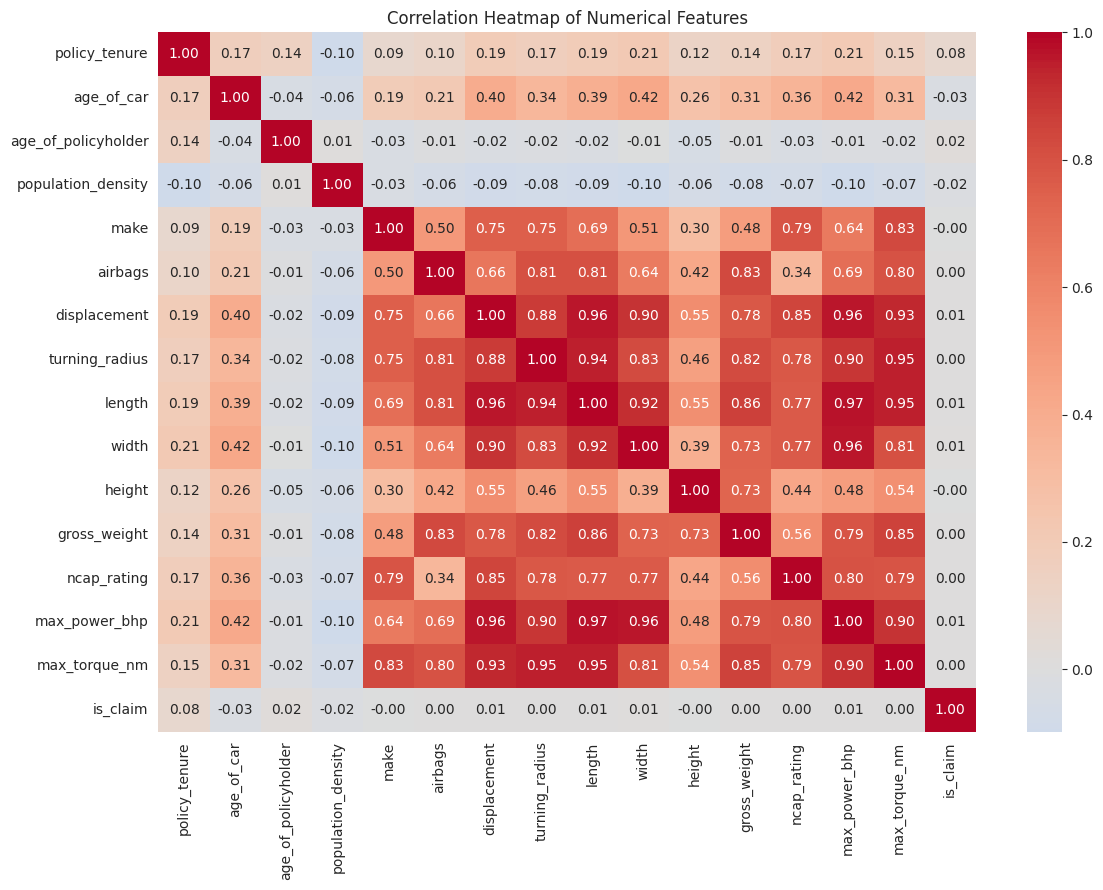

In [45]:
# --------------------------------------------------
# STEP 11: Correlation Heatmap
# --------------------------------------------------

corr_cols = continuous_cols + ['is_claim']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [46]:
# Correlation of numerical features with the target

target_correlations = (
    corr_matrix['is_claim']
    .drop('is_claim')
    .sort_values(key=abs, ascending=False)
)

print("Correlation with is_claim:")
display(target_correlations.to_frame(name='Correlation'))

Correlation with is_claim:


,Correlation
policy_tenure,0.078747
age_of_car,-0.028175
age_of_policyholder,0.022318
population_density,-0.016609
width,0.009947
max_power_bhp,0.007698
displacement,0.007678
length,0.006495
max_torque_nm,0.004294
gross_weight,0.003894


In [47]:
# --------------------------------------------------
# Strongest correlations among predictor variables
# --------------------------------------------------

feature_corr = df[continuous_cols].corr()

# Get upper triangle only to avoid duplicate pairs
upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

strong_correlations = (
    upper_triangle
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("Strongest feature-to-feature correlations:")
display(
    strong_correlations.head(10).to_frame(
        name='Correlation'
    )
)

Strongest feature-to-feature correlations:


Correlation
length         max_power_bhp     0.972989
displacement   max_power_bhp     0.962626
               length            0.961655
width          max_power_bhp     0.959613
length         max_torque_nm     0.952065
turning_radius max_torque_nm     0.946552
               length            0.944899
displacement   max_torque_nm     0.931233
length         width             0.915918
displacement   width             0.899302

In [48]:
# --------------------------------------------------
# STEP 12: Variance Inflation Factor (VIF)
# --------------------------------------------------

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = df[continuous_cols].copy()

vif_results = pd.DataFrame()

vif_results['Feature'] = vif_data.columns

vif_results['VIF'] = [
    variance_inflation_factor(
        vif_data.values,
        i
    )
    for i in range(vif_data.shape[1])
]

vif_results = vif_results.sort_values(
    'VIF',
    ascending=False
).reset_index(drop=True)

display(vif_results)

,Feature,VIF
0,length,36376.968529
1,turning_radius,13753.820608
2,width,5166.084340
3,height,2053.425796
4,displacement,1614.204809
5,gross_weight,798.092023
6,max_power_bhp,372.765986
7,max_torque_nm,306.305423
8,make,59.647198
9,airbags,52.962460


### VIF Interpretation

The VIF analysis indicates substantial multicollinearity among several vehicle-related numerical features. Variables such as length, turning radius, width, height, displacement, gross weight, max power and max torque show very high VIF values, indicating strong overlap in the information captured by these predictors.

In contrast, age of car, policy tenure, age of policyholder and population density have low VIF values, suggesting limited multicollinearity.

These findings will be considered during feature selection/model preparation to avoid redundant predictors and improve model stability.


## Task 1.4 — Feature Engineering

Derived, business-relevant features (adapted to this vehicle-insurance dataset — the exact
feature names suggested in the brief, e.g. `Mileage_Band`/`Credit_Score_Segment`, map to the
closest available signals here: vehicle age, safety equipment, and area density):

| Engineered feature | Rationale |
|---|---|
| `vehicle_age_band` | Buckets `age_of_car` into Low/Medium/High age bands — underwriters reason in bands, not continuous years, and this captures potential non-linear age effects. |
| `policyholder_age_band` | Buckets `age_of_policyholder` similarly — driver age is a classic actuarial risk factor. |
| `density_band` | Buckets `population_density` into Low/Medium/High — proxies traffic exposure / accident opportunity. |
| `safety_equipment_score` | Sum of all binary safety-feature flags (ESC, TPMS, parking sensors/camera, airbags presence, brake assist, etc.) — a single composite "how well-equipped is this vehicle" signal, replacing many sparse individual flags. |
| `power_to_weight_ratio` | `power_bhp / gross_weight` — a standard vehicle-performance metric; higher-performance cars are often associated with different risk profiles. |
| `low_safety_high_exposure_flag` | Flags vehicles with below-median safety score **and** above-median area density — a composite "elevated exposure" risk flag analogous to a `High_Risk_Driver_Flag`. |


In [49]:
# --------------------------------------------------
# STEP 13: Feature Engineering
# --------------------------------------------------

# Vehicle power-to-weight ratio
df['power_to_weight_ratio'] = (
    df['max_power_bhp'] / df['gross_weight']
)

# Vehicle torque-to-weight ratio
df['torque_to_weight_ratio'] = (
    df['max_torque_nm'] / df['gross_weight']
)

# Vehicle age relative to policy tenure
df['car_age_policy_ratio'] = (
    df['age_of_car'] / (df['policy_tenure'] + 0.01)
)

print("Feature engineering completed.")

Feature engineering completed.


In [50]:
# Check engineered features

engineered_cols = [
    'power_to_weight_ratio',
    'torque_to_weight_ratio',
    'car_age_policy_ratio'
]

display(df[engineered_cols].describe())

,power_to_weight_ratio,torque_to_weight_ratio,car_age_policy_ratio
count,58592.000000,58592.000000,58592.000000
mean,0.056021,0.093052,0.289591
std,0.015706,0.040444,0.730716
min,0.034059,0.050633,0.000000
25%,0.034059,0.050633,0.036719
50%,0.065959,0.084644,0.098275
75%,0.066292,0.145349,0.226493
max,0.093140,0.190295,16.442355


In [51]:
# --------------------------------------------------
# Check engineered features for missing/infinite values
# --------------------------------------------------

print("Missing values:")
print(df[engineered_cols].isnull().sum())

print("\nInfinite values:")
print(np.isinf(df[engineered_cols]).sum())

Missing values:
power_to_weight_ratio     0
torque_to_weight_ratio    0
car_age_policy_ratio      0
dtype: int64

Infinite values:
power_to_weight_ratio     0
torque_to_weight_ratio    0
car_age_policy_ratio      0
dtype: int64


In [52]:
# --------------------------------------------------
# STEP 14: VIF after Feature Engineering
# --------------------------------------------------

vif_features = continuous_cols + engineered_cols

vif_df = df[vif_features].copy()

vif_results_engineered = pd.DataFrame({
    'Feature': vif_df.columns,
    'VIF': [
        variance_inflation_factor(
            vif_df.values,
            i
        )
        for i in range(vif_df.shape[1])
    ]
})

vif_results_engineered = (
    vif_results_engineered
    .sort_values('VIF', ascending=False)
    .reset_index(drop=True)
)

display(vif_results_engineered)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,make,inf
1,airbags,inf
2,max_torque_nm,inf
3,power_to_weight_ratio,inf
4,turning_radius,inf
5,displacement,inf
6,length,inf
7,width,inf
8,gross_weight,inf
9,height,inf


In [68]:
# --------------------------------------------------
# STEP 15: Separate Features and Target
# --------------------------------------------------

X = df.drop(columns=['is_claim', 'policy_id'])
y = df['is_claim']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (58592, 96)
Target shape: (58592,)

Target distribution:
is_claim
0    54844
1     3748
Name: count, dtype: int64


In [54]:
# --------------------------------------------------
# STEP 16: Train-Test Split
# --------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (46873, 90)
Testing set shape: (11719, 90)

Training target distribution:
is_claim
0    0.93604
1    0.06396
Name: proportion, dtype: float64

Testing target distribution:
is_claim
0    0.936001
1    0.063999
Name: proportion, dtype: float64


In [55]:
stratify=y

In [57]:
# --------------------------------------------------
# Check non-numeric columns before scaling
# --------------------------------------------------

non_numeric_cols = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Non-numeric columns in X:")
print(non_numeric_cols)

Non-numeric columns in X:
['policy_id', 'model', 'max_torque', 'max_power', 'area_cluster_C1', 'area_cluster_C10', 'area_cluster_C11', 'area_cluster_C12', 'area_cluster_C13', 'area_cluster_C14', 'area_cluster_C15', 'area_cluster_C16', 'area_cluster_C17', 'area_cluster_C18', 'area_cluster_C19', 'area_cluster_C2', 'area_cluster_C20', 'area_cluster_C21', 'area_cluster_C22', 'area_cluster_C3', 'area_cluster_C4', 'area_cluster_C5', 'area_cluster_C6', 'area_cluster_C7', 'area_cluster_C8', 'area_cluster_C9', 'segment_A', 'segment_B1', 'segment_B2', 'segment_C1', 'segment_C2', 'segment_Utility', 'fuel_type_CNG', 'fuel_type_Diesel', 'fuel_type_Petrol', 'engine_type_1.0 SCe', 'engine_type_1.2 L K Series Engine', 'engine_type_1.2 L K12N Dualjet', 'engine_type_1.5 L U2 CRDi', 'engine_type_1.5 Turbocharged Revotorq', 'engine_type_1.5 Turbocharged Revotron', 'engine_type_F8D Petrol Engine', 'engine_type_G12B', 'engine_type_K Series Dual jet', 'engine_type_K10C', 'engine_type_i-DTEC', 'rear_brakes_ty

In [58]:
# --------------------------------------------------
# STEP 17A: Prepare model-ready features
# --------------------------------------------------

# Work on a copy
X_model = X.copy()

# Drop identifier and original text columns that are no longer needed
columns_to_drop = [
    'policy_id',
    'max_torque',
    'max_power',
    'model'
]

X_model = X_model.drop(columns=columns_to_drop)

# Convert remaining one-hot/object columns to numeric
for col in X_model.columns:
    if X_model[col].dtype == 'object':
        X_model[col] = pd.to_numeric(
            X_model[col],
            errors='coerce'
        )

print("Model-ready feature shape:", X_model.shape)

print("\nRemaining non-numeric columns:")
print(
    X_model.select_dtypes(exclude=np.number).columns.tolist()
)

print("\nMissing values created during conversion:")
print(X_model.isnull().sum().sum())

Model-ready feature shape: (58592, 86)

Remaining non-numeric columns:
['area_cluster_C1', 'area_cluster_C10', 'area_cluster_C11', 'area_cluster_C12', 'area_cluster_C13', 'area_cluster_C14', 'area_cluster_C15', 'area_cluster_C16', 'area_cluster_C17', 'area_cluster_C18', 'area_cluster_C19', 'area_cluster_C2', 'area_cluster_C20', 'area_cluster_C21', 'area_cluster_C22', 'area_cluster_C3', 'area_cluster_C4', 'area_cluster_C5', 'area_cluster_C6', 'area_cluster_C7', 'area_cluster_C8', 'area_cluster_C9', 'segment_A', 'segment_B1', 'segment_B2', 'segment_C1', 'segment_C2', 'segment_Utility', 'fuel_type_CNG', 'fuel_type_Diesel', 'fuel_type_Petrol', 'engine_type_1.0 SCe', 'engine_type_1.2 L K Series Engine', 'engine_type_1.2 L K12N Dualjet', 'engine_type_1.5 L U2 CRDi', 'engine_type_1.5 Turbocharged Revotorq', 'engine_type_1.5 Turbocharged Revotron', 'engine_type_F8D Petrol Engine', 'engine_type_G12B', 'engine_type_K Series Dual jet', 'engine_type_K10C', 'engine_type_i-DTEC', 'rear_brakes_type_D

In [59]:
# --------------------------------------------------
# STEP 17B: Train-Test Split on Model-Ready Data
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (46873, 86)
Testing set shape: (11719, 86)

Training target distribution:
is_claim
0    0.93604
1    0.06396
Name: proportion, dtype: float64

Testing target distribution:
is_claim
0    0.936001
1    0.063999
Name: proportion, dtype: float64


In [60]:
# --------------------------------------------------
# STEP 17C: Feature Scaling
# --------------------------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (46873, 86)
Scaled testing data shape: (11719, 86)


In [61]:
# Vehicle age band (age_of_car is normalised; use terciles for balanced bands)
df['vehicle_age_band'] = pd.qcut(df['age_of_car'], q=3, labels=['Low', 'Medium', 'High'])

# Policyholder age band
df['policyholder_age_band'] = pd.qcut(df['age_of_policyholder'], q=3, labels=['Low', 'Medium', 'High'])

# Population density band
df['density_band'] = pd.qcut(df['population_density'], q=3, labels=['Low', 'Medium', 'High'])

print(df[['vehicle_age_band', 'policyholder_age_band', 'density_band']].apply(lambda x: x.value_counts()))

        vehicle_age_band  policyholder_age_band  density_band
Low                21223                  19814         32835
Medium             18419                  19658         12348
High               18950                  19120         13409


In [62]:
# --------------------------------------------------
# STEP 13D: Encode Engineered Categorical Features
# --------------------------------------------------

band_cols = [
    'vehicle_age_band',
    'policyholder_age_band',
    'density_band'
]

df = pd.get_dummies(
    df,
    columns=band_cols,
    drop_first=True,
    dtype=int
)

print("Encoded band features:")
print([
    col for col in df.columns
    if 'age_band' in col or 'density_band' in col
])

Encoded band features:
['vehicle_age_band_Medium', 'vehicle_age_band_High', 'policyholder_age_band_Medium', 'policyholder_age_band_High', 'density_band_Medium', 'density_band_High']


In [63]:
# --------------------------------------------------
# STEP 13E: Final Modeling Dataset
# --------------------------------------------------

# Start with all current features
X_model = df.drop(columns=['is_claim']).copy()

# Drop identifier and redundant original text columns
columns_to_drop = [
    'policy_id',
    'model',
    'max_torque',
    'max_power'
]

X_model = X_model.drop(
    columns=columns_to_drop,
    errors='ignore'
)

# Convert any remaining object columns to numeric
for col in X_model.columns:
    if X_model[col].dtype == 'object':
        X_model[col] = pd.to_numeric(
            X_model[col],
            errors='coerce'
        )

print("Final modeling dataset shape:", X_model.shape)

print("\nRemaining non-numeric columns:")
print(X_model.select_dtypes(exclude=np.number).columns.tolist())

print("\nTotal missing values:")
print(X_model.isnull().sum().sum())

Final modeling dataset shape: (58592, 92)

Remaining non-numeric columns:
['area_cluster_C1', 'area_cluster_C10', 'area_cluster_C11', 'area_cluster_C12', 'area_cluster_C13', 'area_cluster_C14', 'area_cluster_C15', 'area_cluster_C16', 'area_cluster_C17', 'area_cluster_C18', 'area_cluster_C19', 'area_cluster_C2', 'area_cluster_C20', 'area_cluster_C21', 'area_cluster_C22', 'area_cluster_C3', 'area_cluster_C4', 'area_cluster_C5', 'area_cluster_C6', 'area_cluster_C7', 'area_cluster_C8', 'area_cluster_C9', 'segment_A', 'segment_B1', 'segment_B2', 'segment_C1', 'segment_C2', 'segment_Utility', 'fuel_type_CNG', 'fuel_type_Diesel', 'fuel_type_Petrol', 'engine_type_1.0 SCe', 'engine_type_1.2 L K Series Engine', 'engine_type_1.2 L K12N Dualjet', 'engine_type_1.5 L U2 CRDi', 'engine_type_1.5 Turbocharged Revotorq', 'engine_type_1.5 Turbocharged Revotron', 'engine_type_F8D Petrol Engine', 'engine_type_G12B', 'engine_type_K Series Dual jet', 'engine_type_K10C', 'engine_type_i-DTEC', 'rear_brakes_typ

In [64]:
# --------------------------------------------------
# STEP 13F: Convert One-Hot Features to Numeric
# --------------------------------------------------

# Identify remaining object columns
object_cols = X_model.select_dtypes(include='object').columns.tolist()

print("Converting", len(object_cols), "one-hot columns to numeric.")

# Convert string/object values to numeric
for col in object_cols:
    X_model[col] = pd.to_numeric(
        X_model[col],
        errors='coerce'
    )

print("\nRemaining non-numeric columns:")
print(
    X_model.select_dtypes(exclude=np.number).columns.tolist()
)

print("\nTotal missing values:")
print(X_model.isnull().sum().sum())

print("\nFinal modeling dataset shape:")
print(X_model.shape)

Converting 0 one-hot columns to numeric.

Remaining non-numeric columns:
['area_cluster_C1', 'area_cluster_C10', 'area_cluster_C11', 'area_cluster_C12', 'area_cluster_C13', 'area_cluster_C14', 'area_cluster_C15', 'area_cluster_C16', 'area_cluster_C17', 'area_cluster_C18', 'area_cluster_C19', 'area_cluster_C2', 'area_cluster_C20', 'area_cluster_C21', 'area_cluster_C22', 'area_cluster_C3', 'area_cluster_C4', 'area_cluster_C5', 'area_cluster_C6', 'area_cluster_C7', 'area_cluster_C8', 'area_cluster_C9', 'segment_A', 'segment_B1', 'segment_B2', 'segment_C1', 'segment_C2', 'segment_Utility', 'fuel_type_CNG', 'fuel_type_Diesel', 'fuel_type_Petrol', 'engine_type_1.0 SCe', 'engine_type_1.2 L K Series Engine', 'engine_type_1.2 L K12N Dualjet', 'engine_type_1.5 L U2 CRDi', 'engine_type_1.5 Turbocharged Revotorq', 'engine_type_1.5 Turbocharged Revotron', 'engine_type_F8D Petrol Engine', 'engine_type_G12B', 'engine_type_K Series Dual jet', 'engine_type_K10C', 'engine_type_i-DTEC', 'rear_brakes_type

In [65]:
# Safety equipment composite score = sum of binary safety flags
safety_flags = ['is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
                'is_parking_camera', 'is_front_fog_lights', 'is_rear_window_wiper',
                'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist',
                'is_power_door_locks', 'is_central_locking', 'is_power_steering',
                'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
                'is_ecw', 'is_speed_alert']
safety_flags = [c for c in safety_flags if c in df.columns]

df['safety_equipment_score'] = df[safety_flags].sum(axis=1) + df['airbags']

print(df['safety_equipment_score'].describe())

count    58592.000000
mean        12.815504
std          6.698833
min          3.000000
25%          5.000000
50%         13.000000
75%         22.000000
max         22.000000
Name: safety_equipment_score, dtype: float64


In [69]:
# Power-to-weight ratio
df['power_to_weight_ratio'] = df['max_power_bhp'] / df['gross_weight']

# Composite exposure flag: below-median safety score AND above-median density
safety_median = df['safety_equipment_score'].median()
density_median = df['population_density'].median()
df['low_safety_high_exposure_flag'] = (
    (df['safety_equipment_score'] < safety_median) &
    (df['population_density'] > density_median)
).astype(int)

print(df['power_to_weight_ratio'].describe())
print("\nlow_safety_high_exposure_flag distribution:")
print(df['low_safety_high_exposure_flag'].value_counts())

count    58592.000000
mean         0.056021
std          0.015706
min          0.034059
25%          0.034059
50%          0.065959
75%          0.066292
max          0.093140
Name: power_to_weight_ratio, dtype: float64

low_safety_high_exposure_flag distribution:
low_safety_high_exposure_flag
0    46013
1    12579
Name: count, dtype: int64


Claim rate (%) by low_safety_high_exposure_flag:
low_safety_high_exposure_flag
0    6.55
1    5.84
Name: is_claim, dtype: float64


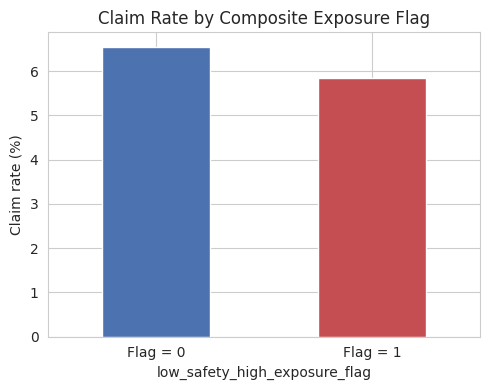

In [71]:
# Validate the new composite flag against claim rate
flag_claim_rate = df.groupby('low_safety_high_exposure_flag')['is_claim'].mean() * 100
print("Claim rate (%) by low_safety_high_exposure_flag:")
print(flag_claim_rate.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
flag_claim_rate.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_xticklabels(['Flag = 0', 'Flag = 1'], rotation=0)
ax.set_ylabel('Claim rate (%)')
ax.set_title('Claim Rate by Composite Exposure Flag')
plt.tight_layout()
plt.show()

In [70]:
# One-hot encode the new banded categorical features
# band_cols = ['vehicle_age_band', 'policyholder_age_band', 'density_band']
# df = pd.get_dummies(df, columns=band_cols, drop_first=True)
# print("Shape after encoding engineered bands:", df.shape)


### Multicollinearity check (VIF)

VIF is computed on the **continuous numeric features** (raw + engineered) — this is where
multicollinearity is most meaningful to check; one-hot/frequency-encoded categorical dummies are
excluded from this check, as VIF on sparse dummy sets is not a standard or reliable diagnostic.
Features are dropped iteratively, highest VIF first, until all remaining features are below the
common threshold of 10.

In [72]:
vif_candidates = ['policy_tenure', 'age_of_car', 'age_of_policyholder',
                  'population_density_log', 'displacement', 'cylinder', 'gear_box',
                  'turning_radius', 'length', 'width', 'height', 'gross_weight',
                  'airbags', 'ncap_rating', 'torque_nm', 'torque_rpm',
                  'power_bhp', 'power_rpm', 'safety_equipment_score',
                  'power_to_weight_ratio']
vif_candidates = [c for c in vif_candidates if c in df.columns]

def compute_vif(data, cols):
    X = data[cols].astype(float)
    vif_df = pd.DataFrame({
        'feature': cols,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(len(cols))]
    })
    return vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

vif_cols = vif_candidates.copy()
dropped_features = []

while True:
    vif_result = compute_vif(df, vif_cols)
    top = vif_result.iloc[0]
    if top['VIF'] > 10:
        dropped_features.append((top['feature'], round(top['VIF'], 2)))
        vif_cols.remove(top['feature'])
    else:
        break

print("Features dropped for high VIF (>10):")
for f, v in dropped_features:
    print(f"  {f}: VIF = {v}")

print("\nFinal VIF table (all features retained, VIF <= 10):")
print(vif_result.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Features dropped for high VIF (>10):
  gear_box: VIF = inf
  length: VIF = 152307.35
  displacement: VIF = 48661.48
  turning_radius: VIF = 4448.12
  gross_weight: VIF = 1098.5
  width: VIF = 738.35
  cylinder: VIF = 296.16
  safety_equipment_score: VIF = 149.94
  power_to_weight_ratio: VIF = 32.45
  height: VIF = 21.55

Final VIF table (all features retained, VIF <= 10):
            feature      VIF
age_of_policyholder 4.944164
            airbags 4.168044
      policy_tenure 3.360032
        ncap_rating 3.262687
         age_of_car 2.928900


In [73]:
# Drop the high-VIF raw features (their information is retained via engineered features
# and/or other correlated columns that remain in the dataset)
df = df.drop(columns=[f for f, v in dropped_features])
print("Shape after dropping high-VIF features:", df.shape)

Shape after dropping high-VIF features: (58592, 89)


**Rationale for engineered features kept:**
- `safety_equipment_score` condenses 17 sparse binary flags into a single interpretable score and
  passed the VIF check, so the underlying individual flags can be considered redundant with it for
  linear modelling purposes.
- `power_to_weight_ratio` survived the VIF check independently of raw `power_bhp`/`gross_weight`,
  indicating it captures information not fully redundant with either component alone.
- `vehicle_age_band`, `policyholder_age_band`, `density_band` are retained as categorical bands
  (not part of the VIF check, which applies to continuous features) because they make the
  eventual model's output easier to explain to underwriters ("high vehicle-age band" vs a raw
  normalised float).
- `low_safety_high_exposure_flag` is retained as a business-interpretable composite risk flag
  directly aligned with Business Question 3 (risk segmentation), even though as a binary flag it
  sits outside the continuous-feature VIF check.

## Export the Cleaned, Analysis-Ready Dataset

In [74]:
print("Final dataset shape:", df.shape)
print("\nColumn list:")
print(df.columns.tolist())

df.to_csv('cleaned_dataset.csv', index=False)
print("\nSaved: cleaned_dataset.csv")

Final dataset shape: (58592, 89)

Column list:
['policy_id', 'policy_tenure', 'age_of_car', 'age_of_policyholder', 'population_density', 'make', 'model', 'max_torque', 'max_power', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert', 'ncap_rating', 'is_claim', 'max_power_bhp', 'max_torque_nm', 'area_cluster_C1', 'area_cluster_C10', 'area_cluster_C11', 'area_cluster_C12', 'area_cluster_C13', 'area_cluster_C14', 'area_cluster_C15', 'area_cluster_C16', 'area_cluster_C17', 'area_cluster_C18', 'area_cluster_C19', 'area_cluster_C2', 'area_cluster_C20', 'area_cluster_C21', 'area_cluster_C22', 'area_cluster_C3', 'area_cluster_C4', 'area_cluster_C5', 'area_cluster_C6', 'a

## Summary

- Loaded 58,592 policy records across 44 raw columns; no missing values, no duplicate rows.
- Target (`is_claim`) is strongly imbalanced: ~6.4% claims vs ~93.6% no-claims — carried forward as
  a key modelling consideration for Stage 2.
- `max_torque` / `max_power` compound strings parsed into clean numeric fields; all `Yes`/`No` flags
  converted to binary 0/1.
- Continuous features winsorised at the IQR fences; `population_density` (and other skewed
  features) log-transformed.
- Low-cardinality categoricals one-hot encoded; high-cardinality categoricals frequency encoded.
- Engineered 4 new business-relevant features (age bands, density band, safety score,
  power-to-weight ratio, composite exposure flag) and removed multicollinear raw features via
  iterative VIF filtering (threshold VIF ≤ 10).
- Exported the final analysis-ready dataset as `cleaned_dataset.csv`, ready for Stage 2 (baseline
  logistic regression model building).